# Milestone 1 - Diabetes Prediction
## Preprocessing, Outlier Detection, and Correlation Visualization

This Notebook includes:
- dataset loading and inspection
- preprocessing based on the attached labs and team EDA
- outlier detection
- correlation and visualization plots

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

## Loading the dataset

In [2]:
df = pd.read_csv("Dataset of Diabetes.csv")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (1000, 14)
Columns: ['ID', 'No_Pation', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS']


,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


## Basic dataset overview

In [3]:
print("Data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nExact duplicate rows:", df.duplicated().sum())
print("\nUnique values in Gender:", df["Gender"].unique())
print("Unique values in CLASS:", df["CLASS"].unique())

Data types:
ID             int64
No_Pation      int64
Gender           str
AGE            int64
Urea         float64
Cr             int64
HbA1c        float64
Chol         float64
TG           float64
HDL          float64
LDL          float64
VLDL         float64
BMI          float64
CLASS            str
dtype: object

Missing values:
ID           0
No_Pation    0
Gender       0
AGE          0
Urea         0
Cr           0
HbA1c        0
Chol         0
TG           0
HDL          0
LDL          0
VLDL         0
BMI          0
CLASS        0
dtype: int64

Exact duplicate rows: 0

Unique values in Gender: <StringArray>
['F', 'M', 'f']
Length: 3, dtype: str
Unique values in CLASS: <StringArray>
['N', 'N ', 'P', 'Y', 'Y ']
Length: 5, dtype: str


### Copying the raw data to keep original data safe to compare changes later and to allow mistakes to be undone.

In [4]:
df_raw = df.copy()

## Drop identifier columns
From the team EDA, `ID` and `No_Pation` are identifiers only.

In [5]:
df = df.drop(columns=["ID", "No_Pation"])
print(df.shape)
df.head()

(1000, 12)


,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


## Clean text columns
- remove extra spaces from `CLASS`
- make all `Gender` uppercase

In [6]:
df["CLASS"] = df["CLASS"].astype(str).str.strip()
df["Gender"] = df["Gender"].astype(str).str.strip().str.upper()

print("Unique values in Gender after cleaning:", df["Gender"].unique())
print("Unique values in CLASS after cleaning:", df["CLASS"].unique())

Unique values in Gender after cleaning: <StringArray>
['F', 'M']
Length: 2, dtype: str
Unique values in CLASS after cleaning: <StringArray>
['N', 'P', 'Y']
Length: 3, dtype: str


## Detect content-based duplicates
After removing the identifier columns, we check duplicated medical records.

In [7]:
duplicate_count = df.duplicated().sum()
print("Content-based duplicate rows:", duplicate_count)

duplicates = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())
duplicates.head(20)

Content-based duplicate rows: 174


,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
12,F,30,3.0,42,4.1,4.9,1.3,1.20,3.20,0.5,22.0,N
17,F,30,3.0,42,4.1,4.9,1.3,1.20,3.20,0.5,22.0,N
129,F,30,5.7,53,6.0,5.4,1.7,1.40,3.30,0.7,22.0,P
131,F,30,5.7,53,6.0,5.4,1.7,1.40,3.30,0.7,22.0,P
205,F,33,1.8,31,7.4,3.7,1.2,1.60,1.50,0.5,31.5,Y
211,F,33,1.8,31,7.4,3.7,1.2,1.60,1.50,0.5,31.5,Y
121,F,39,3.0,38,6.4,4.7,1.3,1.10,3.10,0.6,22.0,P
125,F,39,3.0,38,6.4,4.7,1.3,1.10,3.10,0.6,22.0,P
21,F,42,5.0,73,4.5,6.2,1.0,1.10,4.60,0.4,24.0,N
33,F,42,5.0,73,4.5,6.2,1.0,1.10,4.60,0.4,24.0,N


## Remove content-based duplicates
Keep the first occurrence only.

In [8]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing content-based duplicates:", df.shape)
print("Remaining duplicates:", df.duplicated().sum())

Shape after removing content-based duplicates: (826, 12)
Remaining duplicates: 0


## Check medically suspicious values found in the team EDA
Only values explicitly identified in the team EDA are handled here:
Example:
- `Chol == 0`
- `Cr == 800`

In [9]:
print("Rows with Chol == 0:", (df["Chol"] == 0).sum())
print("Rows with Cr == 800:", (df["Cr"] == 800).sum())

df.loc[df["Chol"] == 0, "Chol"] = np.nan
df.loc[df["Cr"] == 800, "Cr"] = np.nan

print("\nMissing values after replacing suspicious values with NaN:")
print(df.isnull().sum())

Rows with Chol == 0: 1
Rows with Cr == 800: 3

Missing values after replacing suspicious values with NaN:
Gender    0
AGE       0
Urea      0
Cr        3
HbA1c     0
Chol      1
TG        0
HDL       0
LDL       0
VLDL      0
BMI       0
CLASS     0
dtype: int64


## Handle missing values
Using the same idea from the preprocessing lab:
- numerical columns -> fill with column mean
- categorical columns -> fill with most frequent value

In [10]:
categorical_cols = ["Gender", "CLASS"]
numerical_cols = [col for col in df.columns if col not in categorical_cols]

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].mean())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Gender    0
AGE       0
Urea      0
Cr        0
HbA1c     0
Chol      0
TG        0
HDL       0
LDL       0
VLDL      0
BMI       0
CLASS     0
dtype: int64


## Final cleaned dataset overview

In [11]:
print("Final shape after Milestone 1 cleaning:", df.shape)
df.describe(include="all")

Final shape after Milestone 1 cleaning: (826, 12)


,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
count,826,826.000000,826.000000,826.000000,826.000000,826.000000,826.00000,826.000000,826.000000,826.000000,826.000000,826
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y
freq,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,690
mean,NaN,53.490315,5.184677,66.359660,8.326344,4.904145,2.39937,1.211804,2.590061,1.774576,29.459274,NaN
std,NaN,8.808427,3.077831,39.962036,2.602589,1.317810,1.45685,0.679610,1.132863,3.517931,4.996676,NaN
min,NaN,20.000000,0.500000,6.000000,0.900000,0.500000,0.30000,0.200000,0.300000,0.100000,19.000000,NaN
25%,NaN,51.000000,3.615000,48.000000,6.500000,4.000000,1.50000,0.900000,1.700000,0.700000,26.000000,NaN
50%,NaN,55.000000,4.600000,59.000000,8.100000,4.800000,2.01500,1.100000,2.500000,1.000000,30.000000,NaN
75%,NaN,59.000000,5.700000,73.000000,10.200000,5.600000,3.00000,1.300000,3.300000,1.500000,33.000000,NaN


## Save the cleaned dataset for Milestone 1

In [12]:
df.to_csv("diabetes_milestone1_cleaned.csv", index=False)
print("Saved: diabetes_milestone1_cleaned.csv")

Saved: diabetes_milestone1_cleaned.csv


# ///////////////CLEANING ENDS HERE ////////////////

# Outlier Detection
The anomaly detection material mentions **boxplot** and **scatter plot** as core tools for detecting outliers.

## Boxplots for all numerical features

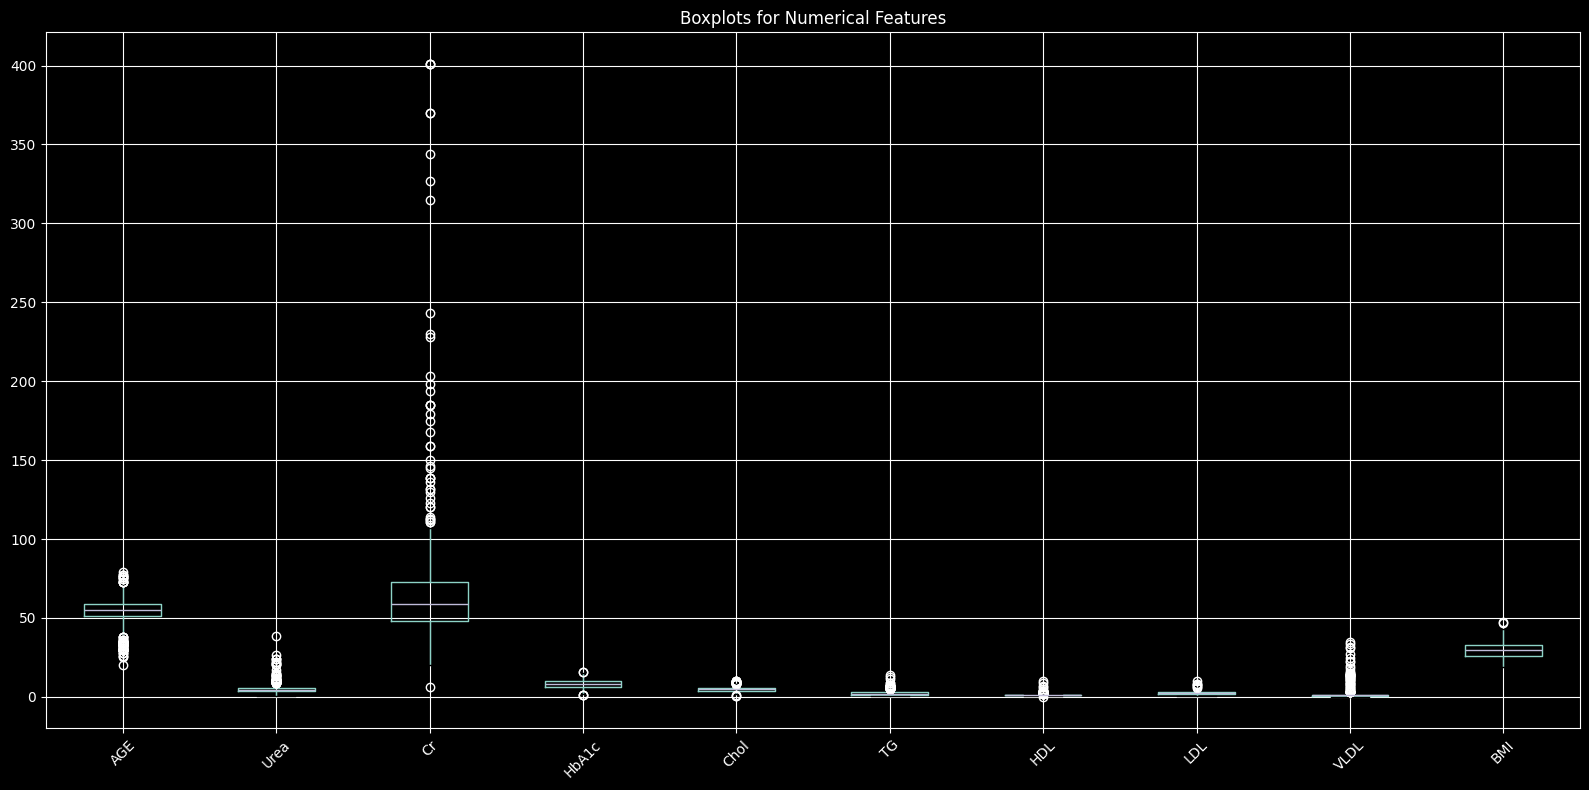

In [13]:
plt.figure(figsize=(16, 8))
df[numerical_cols].boxplot(rot=45)
plt.title("Boxplots for Numerical Features")
plt.tight_layout()
plt.show()

## IQR-based outlier count for each numerical column

In [14]:
outlier_summary = []

for col in numerical_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary.append({
        "feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": outliers.shape[0],
        "outlier_percent": round((outliers.shape[0] / len(df)) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values(by="outlier_count", ascending=False)
outlier_df

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percent
0,AGE,51.000,59.0,8.000,39.0000,71.0000,79,9.56
1,Urea,3.615,5.7,2.085,0.4875,8.8275,56,6.78
8,VLDL,0.700,1.5,0.800,-0.5000,2.7000,54,6.54
2,Cr,48.000,73.0,25.000,10.5000,110.5000,43,5.21
6,HDL,0.900,1.3,0.400,0.3000,1.9000,42,5.08
5,TG,1.500,3.0,1.500,-0.7500,5.2500,36,4.36
4,Chol,4.000,5.6,1.600,1.6000,8.0000,22,2.66
7,LDL,1.700,3.3,1.600,-0.7000,5.7000,7,0.85
3,HbA1c,6.500,10.2,3.700,0.9500,15.7500,5,0.61
9,BMI,26.000,33.0,7.000,15.5000,43.5000,2,0.24


## View outlier rows for one selected feature
[this step used for each feature visual data inspection]

In [15]:
selected_feature = "Cr"

q1 = df[selected_feature].quantile(0.25)
q3 = df[selected_feature].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

feature_outliers = df[(df[selected_feature] < lower) | (df[selected_feature] > upper)]
print("Outliers in", selected_feature, "=", feature_outliers.shape[0])
feature_outliers.head(20)

Outliers in Cr = 43


,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
17,F,49,13.5,175.0,5.1,0.5,1.9,1.3,2.8,0.8,24.0,N
63,F,31,3.9,6.0,5.4,4.4,1.8,1.1,2.6,0.8,22.0,N
81,F,40,5.8,123.0,4.5,4.6,1.5,0.7,3.0,0.6,24.0,N
85,M,50,9.6,203.0,5.4,3.8,5.9,0.5,4.3,1.3,22.0,N
88,F,44,7.3,132.0,4.3,5.2,1.9,2.5,3.0,0.7,21.0,N
89,M,40,22.0,159.0,5.4,3.1,1.6,1.1,1.3,0.7,24.0,N
131,M,30,17.1,344.0,6.0,4.9,1.6,1.7,2.5,0.7,21.0,P
174,M,57,4.6,370.0,6.8,4.0,6.0,2.5,3.5,1.1,37.0,Y
176,M,57,4.6,370.0,6.8,6.1,6.0,2.5,3.5,1.1,37.0,Y
231,F,66,14.1,146.0,8.7,5.8,3.3,1.0,3.4,1.5,33.0,Y


## Scatter plots for possible outlier inspection
These are used to visualize unusual points and variable relationships.

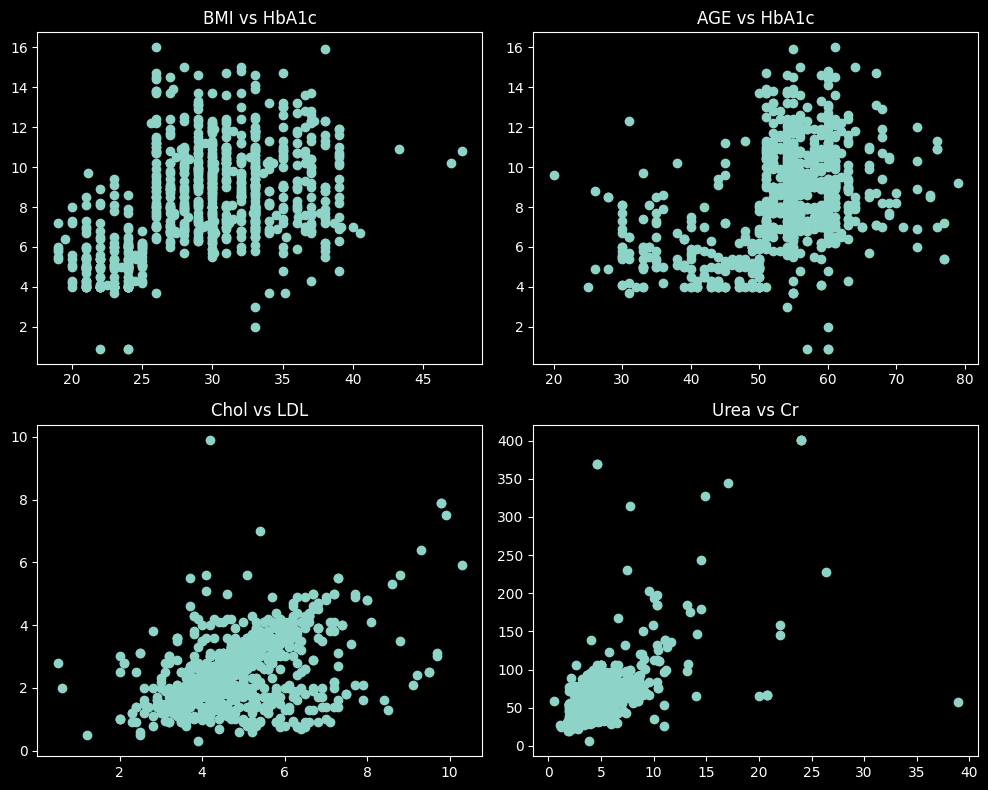

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Plot 1
plt.subplot(2, 2, 1)
plt.scatter(df["BMI"], df["HbA1c"])
plt.title("BMI vs HbA1c")

# Plot 2
plt.subplot(2, 2, 2)
plt.scatter(df["AGE"], df["HbA1c"])
plt.title("AGE vs HbA1c")

# Plot 3
plt.subplot(2, 2, 3)
plt.scatter(df["Chol"], df["LDL"])
plt.title("Chol vs LDL")

# Plot 4
plt.subplot(2, 2, 4)
plt.scatter(df["Urea"], df["Cr"])
plt.title("Urea vs Cr")

plt.tight_layout()
plt.show()

# Data Visualization and Correlation Assessment
This section covers the Milestone 1 requirement for data assessment and correlation relations between variables.

## Class distribution

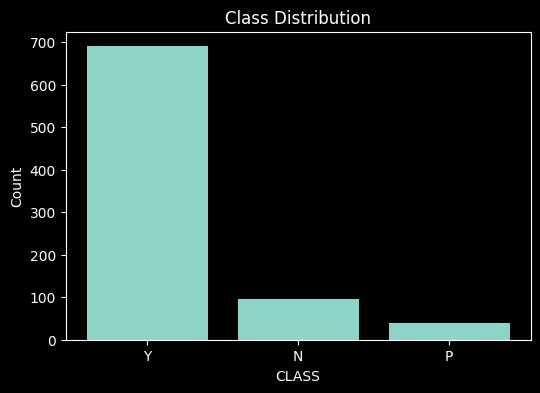

CLASS
Y    690
N     96
P     40
Name: count, dtype: int64
CLASS
Y    83.535109
N    11.622276
P     4.842615
Name: proportion, dtype: float64


In [17]:
class_counts = df["CLASS"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Class Distribution")
plt.xlabel("CLASS")
plt.ylabel("Count")
plt.show()

print(df["CLASS"].value_counts())
print(df["CLASS"].value_counts(normalize=True) * 100)

## Gender distribution

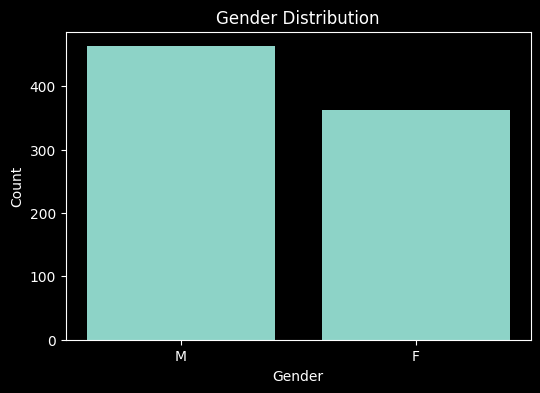

Gender
M    463
F    363
Name: count, dtype: int64
Gender
M    56.053269
F    43.946731
Name: proportion, dtype: float64


In [18]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(gender_counts.index.astype(str), gender_counts.values)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

print(df["Gender"].value_counts())
print(df["Gender"].value_counts(normalize=True) * 100)

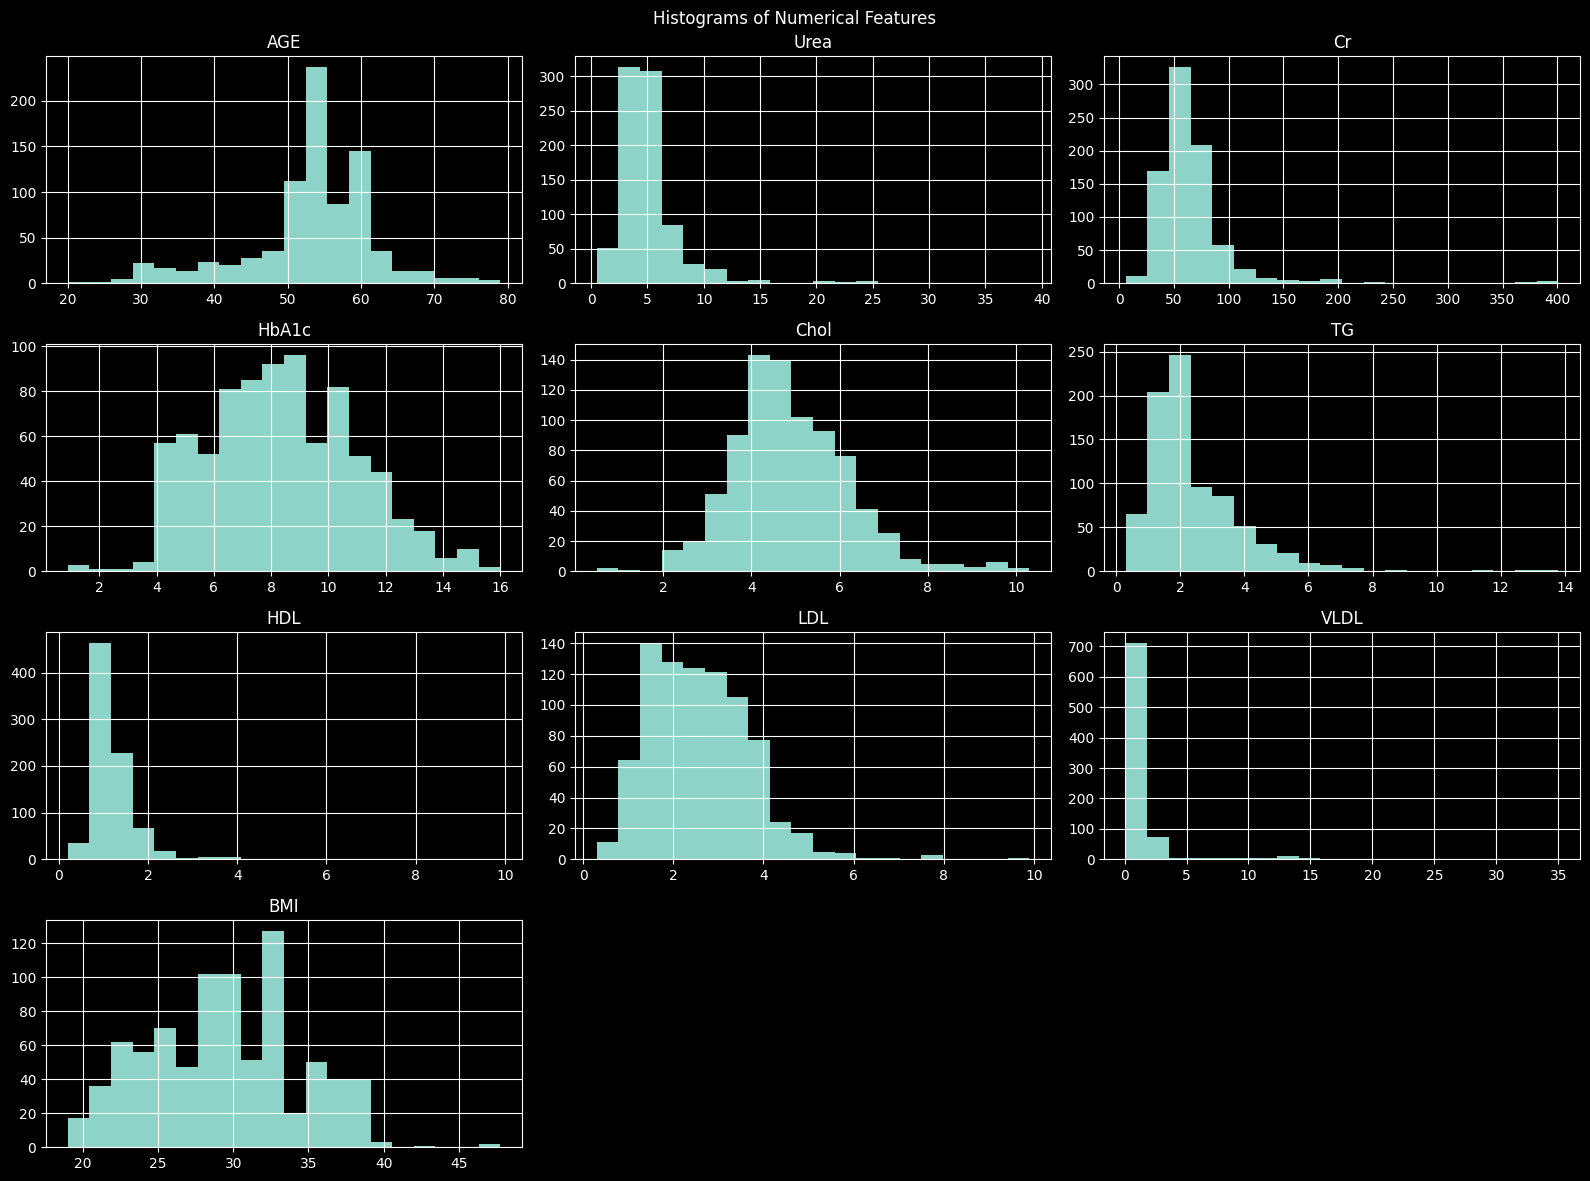

In [19]:
## Histograms for numerical features
df[numerical_cols].hist(figsize=(16, 12), bins=20)
plt.suptitle("Histograms of Numerical Features")
plt.tight_layout()
plt.show()

## Correlation matrix
finds the correlation using Pearson correlation (r)

#### treat all extreme outliers by capping values at the 1st and 99th percentiles.

In [20]:
extrem_cols = ["Urea", "Cr", "TG", "VLDL", "HDL"]

for col in extrem_cols:
    print("Column:", col)
    print("Before:")
    print(df[col].describe())

    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)

    df[col] = df[col].clip(lower, upper)

    print("Lower cap:", lower)
    print("Upper cap:", upper)
    print("After:")
    print(df[col].describe())
    print("-" * 40)

Column: Urea
Before:
count    826.000000
mean       5.184677
std        3.077831
min        0.500000
25%        3.615000
50%        4.600000
75%        5.700000
max       38.900000
Name: Urea, dtype: float64
Lower cap: 2.0
Upper cap: 20.8
After:
count    826.000000
mean       5.145936
std        2.758823
min        2.000000
25%        3.615000
50%        4.600000
75%        5.700000
max       20.800000
Name: Urea, dtype: float64
----------------------------------------
Column: Cr
Before:
count    826.000000
mean      66.359660
std       39.962036
min        6.000000
25%       48.000000
50%       59.000000
75%       73.000000
max      401.000000
Name: Cr, dtype: float64
Lower cap: 24.0
Upper cap: 239.75
After:
count    826.000000
mean      65.171706
std       31.629604
min       24.000000
25%       48.000000
50%       59.000000
75%       73.000000
max      239.750000
Name: Cr, dtype: float64
----------------------------------------
Column: TG
Before:
count    826.00000
mean       2.3993

In [21]:
corr_matrix = df[numerical_cols].corr()
corr_matrix

,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
AGE,1.000000,0.112772,0.049973,0.403664,0.062869,0.153606,-0.035751,0.003165,-0.055985,0.412224
Urea,0.112772,1.000000,0.622992,-0.032256,-0.019632,0.045559,-0.057006,-0.029090,-0.020221,0.048887
Cr,0.049973,0.622992,1.000000,-0.096048,-0.012542,0.101981,-0.031684,0.034294,0.038485,0.003367
HbA1c,0.403664,-0.032256,-0.096048,1.000000,0.200235,0.206571,0.012166,0.002841,0.064728,0.456419
Chol,0.062869,-0.019632,-0.012542,0.200235,1.000000,0.352617,0.081572,0.432655,0.110764,0.034356
TG,0.153606,0.045559,0.101981,0.206571,0.352617,1.000000,-0.093480,0.024525,0.156552,0.126844
HDL,-0.035751,-0.057006,-0.031684,0.012166,0.081572,-0.093480,1.000000,-0.187006,-0.067196,0.065696
LDL,0.003165,-0.029090,0.034294,0.002841,0.432655,0.024525,-0.187006,1.000000,0.081736,-0.068890
VLDL,-0.055985,-0.020221,0.038485,0.064728,0.110764,0.156552,-0.067196,0.081736,1.000000,0.195714
BMI,0.412224,0.048887,0.003367,0.456419,0.034356,0.126844,0.065696,-0.068890,0.195714,1.000000


## Correlation heatmap

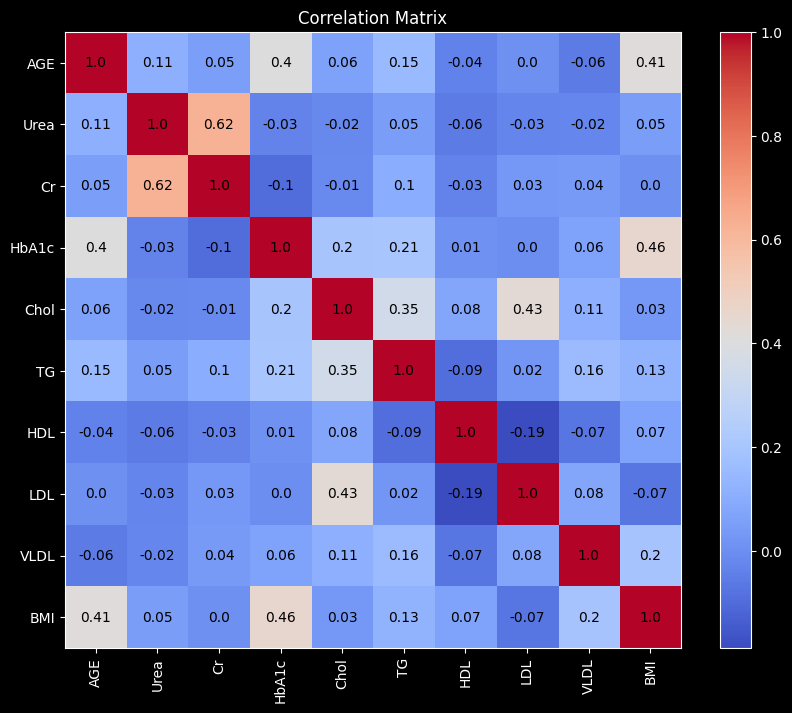

In [22]:
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap="coolwarm")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, round(corr_matrix.iloc[i, j], 2),
                 ha="center", va="center", color="black")

plt.title("Correlation Matrix")
plt.colorbar()
plt.show()

## Top correlated pairs

In [23]:
corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
corr_pairs = corr_pairs.stack().reset_index()
corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]
corr_pairs["Abs_Correlation"] = corr_pairs["Correlation"].abs()

top_corr_pairs = corr_pairs.sort_values(by="Abs_Correlation", ascending=False)
top_corr_pairs.head(15)

,Feature_1,Feature_2,Correlation,Abs_Correlation
12,Urea,Cr,0.622992,0.622992
39,HbA1c,BMI,0.456419,0.456419
47,Chol,LDL,0.432655,0.432655
9,AGE,BMI,0.412224,0.412224
3,AGE,HbA1c,0.403664,0.403664
45,Chol,TG,0.352617,0.352617
35,HbA1c,TG,0.206571,0.206571
34,HbA1c,Chol,0.200235,0.200235
89,VLDL,BMI,0.195714,0.195714
67,HDL,LDL,-0.187006,0.187006


##Cap extreme outliers at 1st and 99th percentiles
This cell treats extreme outliers by capping values at the 1st and 99th percentiles.

In [24]:
winsor_cols = ["Urea", "Cr", "TG", "VLDL", "HDL"]

for col in winsor_cols:
    print("Column:", col)
    print("Before:")
    print(df[col].describe())

    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)

    df[col] = df[col].clip(lower, upper)

    print("Lower cap:", lower)
    print("Upper cap:", upper)
    print("After:")
    print(df[col].describe())
    print("-" * 40)

Column: Urea
Before:
count    826.000000
mean       5.145936
std        2.758823
min        2.000000
25%        3.615000
50%        4.600000
75%        5.700000
max       20.800000
Name: Urea, dtype: float64
Lower cap: 2.0
Upper cap: 20.8
After:
count    826.000000
mean       5.145936
std        2.758823
min        2.000000
25%        3.615000
50%        4.600000
75%        5.700000
max       20.800000
Name: Urea, dtype: float64
----------------------------------------
Column: Cr
Before:
count    826.000000
mean      65.171706
std       31.629604
min       24.000000
25%       48.000000
50%       59.000000
75%       73.000000
max      239.750000
Name: Cr, dtype: float64
Lower cap: 24.0
Upper cap: 237.3125
After:
count    826.000000
mean      65.145147
std       31.483512
min       24.000000
25%       48.000000
50%       59.000000
75%       73.000000
max      237.312500
Name: Cr, dtype: float64
----------------------------------------
Column: TG
Before:
count    826.000000
mean       2.3

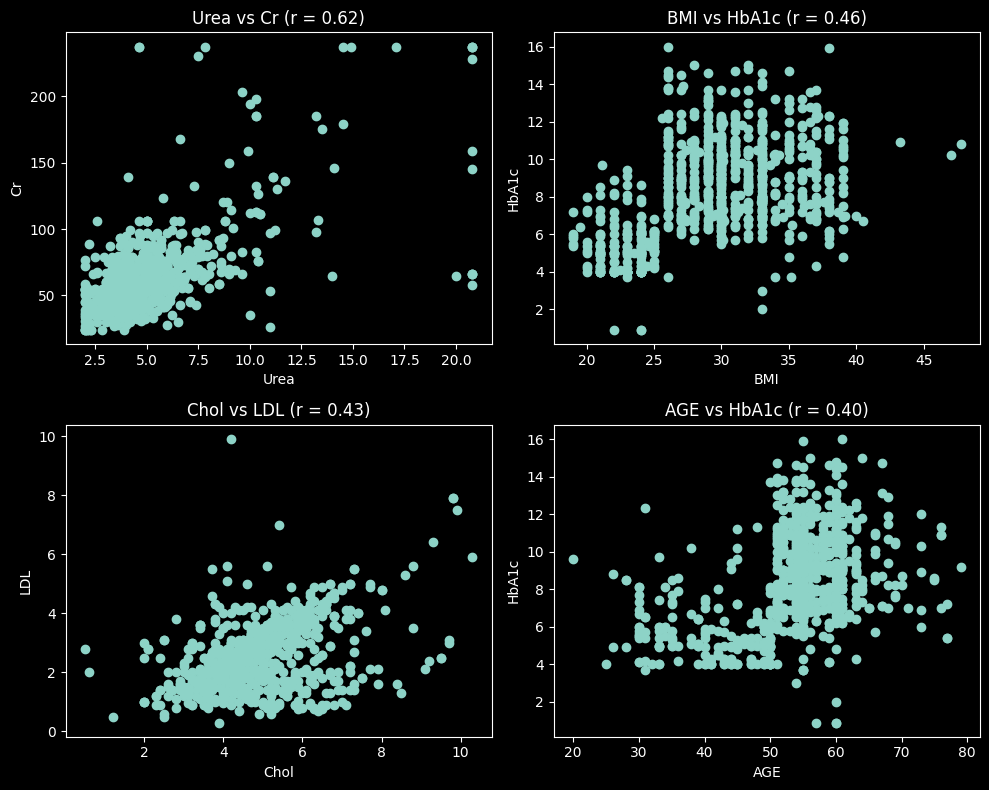

In [25]:
#Ploting scatter plots for the last time after removing the 1st and 99th percentile
plt.figure(figsize=(10, 8))

# Plot 1

r4 = df["Urea"].corr(df["Cr"])
plt.subplot(2, 2, 1)
plt.scatter(df["Urea"], df["Cr"])
plt.title(f"Urea vs Cr (r = {r4:.2f})")
plt.xlabel("Urea")
plt.ylabel("Cr")

# Plot 2
r1 = df["BMI"].corr(df["HbA1c"])
plt.subplot(2, 2, 2)
plt.scatter(df["BMI"], df["HbA1c"])
plt.title(f"BMI vs HbA1c (r = {r1:.2f})")
plt.xlabel("BMI")
plt.ylabel("HbA1c")

# Plot 3
r3 = df["Chol"].corr(df["LDL"])
plt.subplot(2, 2, 3)
plt.scatter(df["Chol"], df["LDL"])
plt.title(f"Chol vs LDL (r = {r3:.2f})")
plt.xlabel("Chol")
plt.ylabel("LDL")

# Plot 4

r2 = df["AGE"].corr(df["HbA1c"])
plt.subplot(2, 2, 4)
plt.scatter(df["AGE"], df["HbA1c"])
plt.title(f"AGE vs HbA1c (r = {r2:.2f})")
plt.xlabel("AGE")
plt.ylabel("HbA1c")

plt.tight_layout()
plt.show()

## Normalization of numerical columns and coumn names

In [26]:
df_normalized = df.copy()

df_normalized.columns = (
    df_normalized.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^\w]+", "_", regex=True)
    .str.strip("_")
)

numerical_cols = df_normalized.select_dtypes(include="number").columns

scaler = MinMaxScaler()
df_normalized[numerical_cols] = scaler.fit_transform(df_normalized[numerical_cols])

df_normalized.head()

,gender,age,urea,cr,hba1c,chol,tg,hdl,ldl,vldl,bmi,class
0,F,0.508475,0.143617,0.103135,0.264901,0.377551,0.046065,0.612903,0.114583,0.01076,0.173913,N
1,M,0.101695,0.132979,0.178142,0.264901,0.326531,0.122841,0.193548,0.187500,0.01614,0.139130,N
2,M,0.220339,0.271277,0.103135,0.264901,0.448980,0.061420,0.096774,0.177083,0.00538,0.069565,N
3,F,0.423729,0.015957,0.000000,0.205298,0.244898,0.061420,0.161290,0.125000,0.00538,0.069565,N
4,F,0.508475,0.000000,0.121887,0.205298,0.316327,0.107486,0.129032,0.187500,0.01614,0.173913,N


## Save Normalized dataset

In [27]:
df_normalized.to_csv("diabetes_milestone1_normalized.csv", index=False)
print("Saved: diabetes_milestone1_normalized.csv")

Saved: diabetes_milestone1_normalized.csv


# Final Files Created

In [28]:
import os

for file_name in [
    "diabetes_milestone1_cleaned.csv",
    "diabetes_milestone1_normalized.csv"
]:
    print(file_name, "->", os.path.exists(file_name))

diabetes_milestone1_cleaned.csv -> True
diabetes_milestone1_normalized.csv -> True
